In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error
import glob

# Load data - same pattern as load_data.ipynb
FOLDER = "hr-2_20251209_DM-1_NS-2"
DATA_DIR = "data"

# Find all NPZ files in the folder
folder_path = os.path.join(DATA_DIR, FOLDER)
files = sorted(glob.glob(os.path.join(folder_path, "*.npz")))

print(f"Found {len(files)} files:")
for f in files:
    print(f"  {os.path.basename(f)}")

# Load and combine all data
all_time = []
all_temp = []
all_hr = []

for filepath in files:
    data = np.load(filepath, allow_pickle=True)
    all_time.append(data['time'].flatten())
    all_temp.append(data['data_F'].flatten())
    all_hr.append(data['labels'].flatten())

# Combine into single arrays
time = np.concatenate(all_time)
temperature = np.concatenate(all_temp)
heart_rate = np.concatenate(all_hr)

# Remove NaN values for analysis
valid_mask = np.isfinite(heart_rate) & np.isfinite(temperature)
time_clean = time[valid_mask]
temp_clean = temperature[valid_mask]
hr_clean = heart_rate[valid_mask]

print(f"\nTotal samples: {len(temperature)}")
print(f"Valid samples (no NaN): {len(temp_clean)}")
print(f"Temperature range: {temp_clean.min():.2f} to {temp_clean.max():.2f} °F")
print(f"Heart rate range: {hr_clean.min():.2f} to {hr_clean.max():.2f} bpm")


Found 2 files:
  tempF_dur-1.00min_fs-200Hz_idx-000_label-T.npz
  tempF_dur-1.00min_fs-200Hz_idx-001_label-T.npz

Total samples: 24002
Valid samples (no NaN): 23998
Temperature range: 98.80 to 99.59 °F
Heart rate range: 57.58 to 83.32 bpm


SIMPLE LINEAR MODEL: Temperature ~ Heart Rate
Model: temp = -0.0004 * hr + 99.3033
R² score: 0.0003
RMSE: 0.1082 °F
Slope: -0.0004 °F/bpm
Intercept: 99.3033 °F


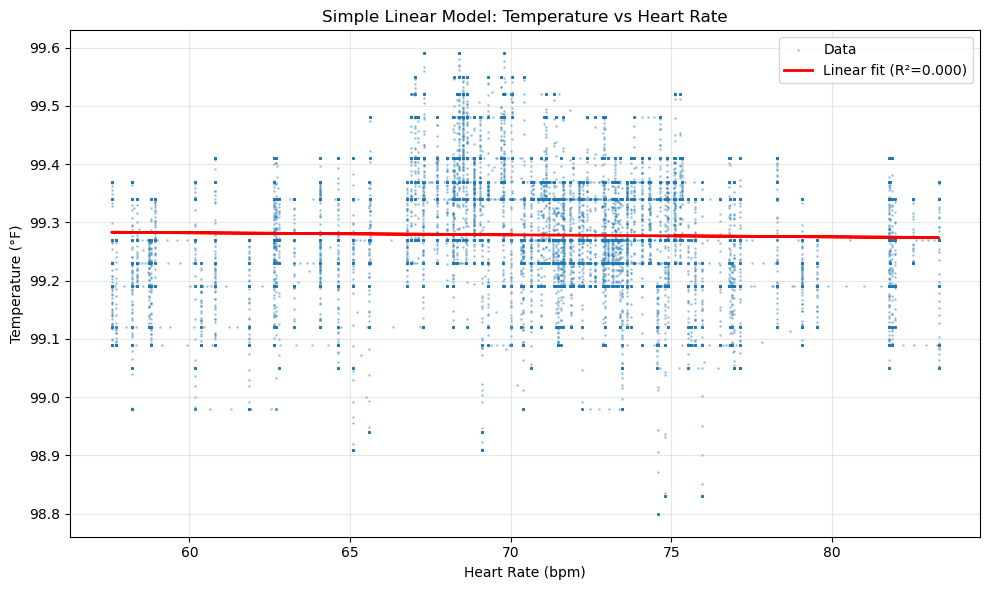

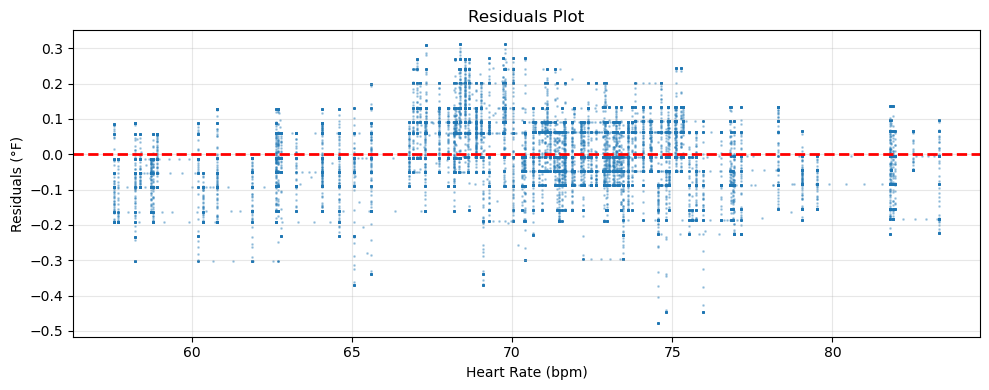

In [3]:
# 1. Simple Linear Model: Temperature ~ Heart Rate
# Model: temp = a * hr + b

# Prepare data
X = hr_clean.reshape(-1, 1)  # Heart rate as feature
y = temp_clean  # Temperature as target

# Fit linear model
linear_model = LinearRegression()
linear_model.fit(X, y)

# Predictions
y_pred = linear_model.predict(X)

# Metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
slope = linear_model.coef_[0]
intercept = linear_model.intercept_

print("=" * 60)
print("SIMPLE LINEAR MODEL: Temperature ~ Heart Rate")
print("=" * 60)
print(f"Model: temp = {slope:.4f} * hr + {intercept:.4f}")
print(f"R² score: {r2:.4f}")
print(f"RMSE: {rmse:.4f} °F")
print(f"Slope: {slope:.4f} °F/bpm")
print(f"Intercept: {intercept:.4f} °F")

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(hr_clean, temp_clean, alpha=0.3, s=1, label='Data')
plt.plot(hr_clean, y_pred, 'r-', linewidth=2, label=f'Linear fit (R²={r2:.3f})')
plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Temperature (°F)')
plt.title('Simple Linear Model: Temperature vs Heart Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residuals plot
residuals = y - y_pred
plt.figure(figsize=(10, 4))
plt.scatter(hr_clean, residuals, alpha=0.3, s=1)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Residuals (°F)')
plt.title('Residuals Plot')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


RIDGE REGRESSION: Temperature ~ Heart Rate

Alpha = 0.01:
  R² score: 0.0003
  RMSE: 0.1082 °F
  Slope: -0.0004 °F/bpm
  Intercept: 99.3033 °F

Alpha = 0.10:
  R² score: 0.0003
  RMSE: 0.1082 °F
  Slope: -0.0004 °F/bpm
  Intercept: 99.3033 °F

Alpha = 1.00:
  R² score: 0.0003
  RMSE: 0.1082 °F
  Slope: -0.0004 °F/bpm
  Intercept: 99.3033 °F

Alpha = 10.00:
  R² score: 0.0003
  RMSE: 0.1082 °F
  Slope: -0.0004 °F/bpm
  Intercept: 99.3033 °F

Alpha = 100.00:
  R² score: 0.0003
  RMSE: 0.1082 °F
  Slope: -0.0004 °F/bpm
  Intercept: 99.3033 °F

Best model (alpha=1.00):
  R² score: 0.0003
  RMSE: 0.1082 °F


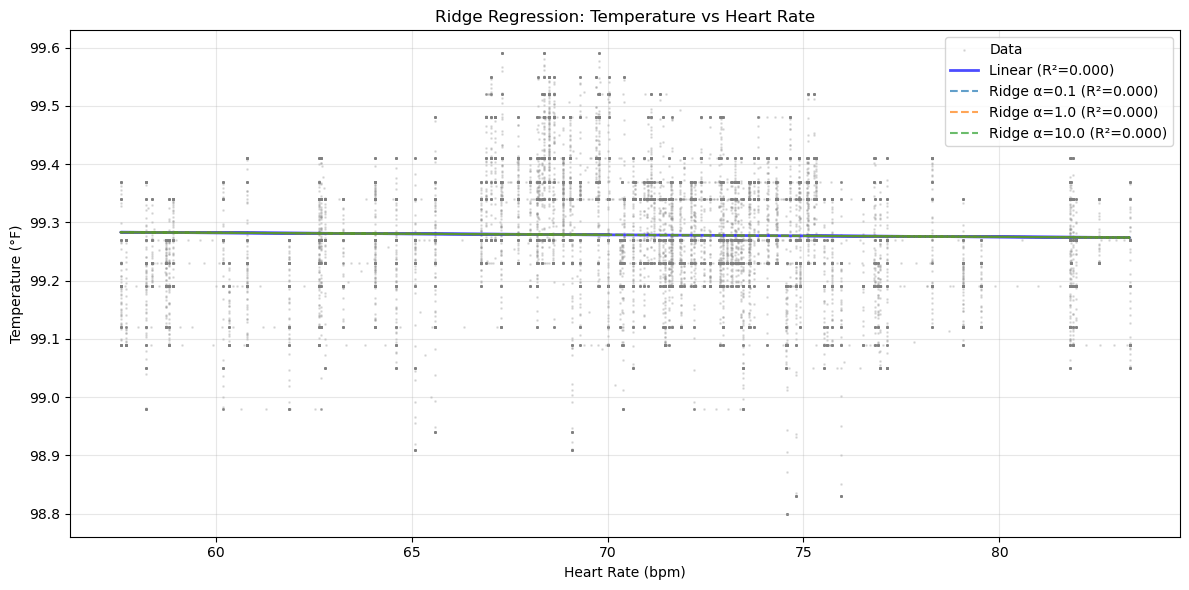

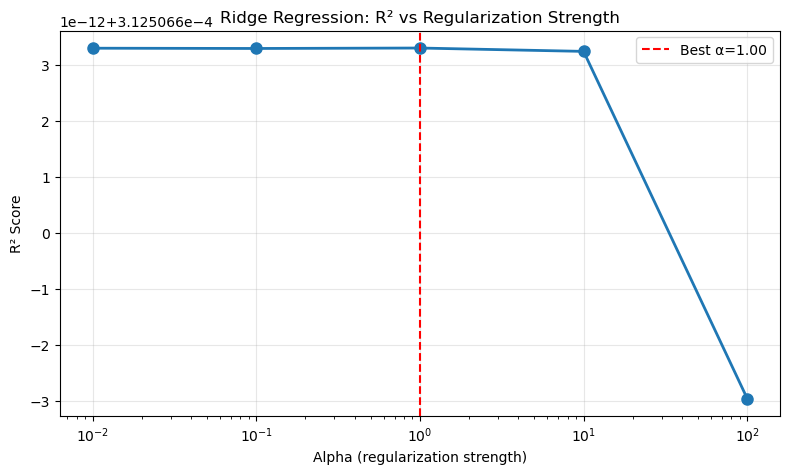

In [4]:
# 2. Ridge Regression: Temperature ~ Heart Rate
# Ridge regression adds L2 regularization to prevent overfitting

# Prepare data (same as before)
X = hr_clean.reshape(-1, 1)
y = temp_clean

# Try different alpha values (regularization strength)
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_models = {}
ridge_scores = {}

print("=" * 60)
print("RIDGE REGRESSION: Temperature ~ Heart Rate")
print("=" * 60)

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X, y)
    y_pred_ridge = ridge_model.predict(X)
    
    r2_ridge = r2_score(y, y_pred_ridge)
    rmse_ridge = np.sqrt(mean_squared_error(y, y_pred_ridge))
    
    ridge_models[alpha] = ridge_model
    ridge_scores[alpha] = {'r2': r2_ridge, 'rmse': rmse_ridge}
    
    print(f"\nAlpha = {alpha:.2f}:")
    print(f"  R² score: {r2_ridge:.4f}")
    print(f"  RMSE: {rmse_ridge:.4f} °F")
    print(f"  Slope: {ridge_model.coef_[0]:.4f} °F/bpm")
    print(f"  Intercept: {ridge_model.intercept_:.4f} °F")

# Find best alpha (highest R²)
best_alpha = max(ridge_scores.keys(), key=lambda a: ridge_scores[a]['r2'])
best_model = ridge_models[best_alpha]
y_pred_best = best_model.predict(X)

print(f"\n{'='*60}")
print(f"Best model (alpha={best_alpha:.2f}):")
print(f"  R² score: {ridge_scores[best_alpha]['r2']:.4f}")
print(f"  RMSE: {ridge_scores[best_alpha]['rmse']:.4f} °F")
print(f"{'='*60}")

# Plot comparison
plt.figure(figsize=(12, 6))
plt.scatter(hr_clean, temp_clean, alpha=0.2, s=1, label='Data', color='gray')

# Plot linear model
plt.plot(hr_clean, y_pred, 'b-', linewidth=2, label=f'Linear (R²={r2:.3f})', alpha=0.7)

# Plot ridge models for a few alphas
for alpha in [0.1, 1.0, 10.0]:
    if alpha in ridge_models:
        y_pred_ridge = ridge_models[alpha].predict(X)
        plt.plot(hr_clean, y_pred_ridge, '--', linewidth=1.5, 
                label=f'Ridge α={alpha} (R²={ridge_scores[alpha]["r2"]:.3f})', alpha=0.7)

plt.xlabel('Heart Rate (bpm)')
plt.ylabel('Temperature (°F)')
plt.title('Ridge Regression: Temperature vs Heart Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot R² vs alpha
plt.figure(figsize=(8, 5))
alphas_sorted = sorted(ridge_scores.keys())
r2_values = [ridge_scores[a]['r2'] for a in alphas_sorted]
plt.semilogx(alphas_sorted, r2_values, 'o-', linewidth=2, markersize=8)
plt.axvline(x=best_alpha, color='r', linestyle='--', label=f'Best α={best_alpha:.2f}')
plt.xlabel('Alpha (regularization strength)')
plt.ylabel('R² Score')
plt.title('Ridge Regression: R² vs Regularization Strength')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


HEART RATE BINNING (4 bpm intervals)
Total bins: 7
Bin range: 56 to 84 bpm

Bin distribution:
Bin (bpm)       Count      Percentage   Mean Temp (°F)  Std Temp (°F)  
----------------------------------------------------------------------
56-60           1357         5.65%        99.22            0.08
60-64           1724         7.18%        99.23            0.10
64-68           2617        10.91%        99.30            0.11
68-72           8221        34.26%        99.31            0.11
72-76           7515        31.32%        99.27            0.10
76-80           1555         6.48%        99.22            0.09
80-84           1009         4.20%        99.23            0.10


C:\Users\dnxjc\AppData\Local\Temp\ipykernel_18564\1910947652.py:93: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(bin_data_list, labels=[bin_labels[i] for i in unique_bins],


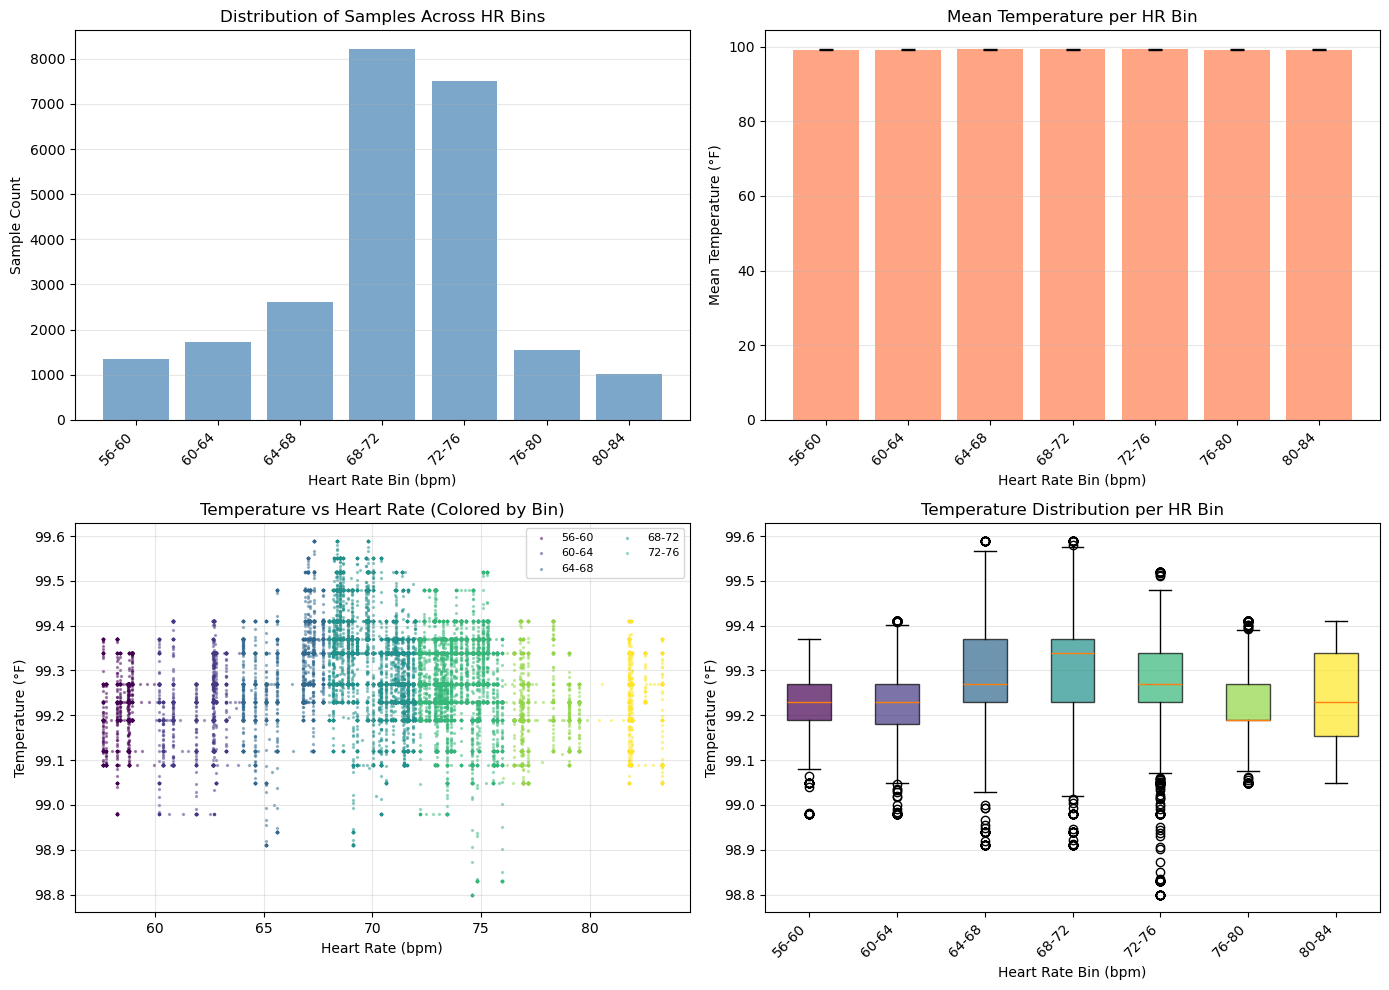


Binned data stored in 'binned_data' dictionary
Keys: bin labels (e.g., '68-72', '72-76', ...)
Values: dict with 'temperatures', 'heart_rates', 'count', 'mean_temp', 'std_temp', 'mean_hr'


In [5]:
# 3. Bin samples into heart rate categories (4 bpm intervals)

# Determine bin edges (every 4 bpm)
hr_min = np.floor(hr_clean.min() / 4) * 4
hr_max = np.ceil(hr_clean.max() / 4) * 4
bin_edges = np.arange(hr_min, hr_max + 4, 4)

# Create bins
bin_indices = np.digitize(hr_clean, bin_edges) - 1  # -1 because digitize uses 1-based indexing
bin_indices = np.clip(bin_indices, 0, len(bin_edges) - 2)  # Clip to valid range

# Create bin labels (e.g., "68-72", "72-76", etc.)
bin_labels = []
for i in range(len(bin_edges) - 1):
    bin_labels.append(f"{bin_edges[i]:.0f}-{bin_edges[i+1]:.0f}")

# Count samples in each bin
unique_bins, bin_counts = np.unique(bin_indices, return_counts=True)

print("=" * 60)
print("HEART RATE BINNING (4 bpm intervals)")
print("=" * 60)
print(f"Total bins: {len(bin_labels)}")
print(f"Bin range: {hr_min:.0f} to {hr_max:.0f} bpm")
print(f"\nBin distribution:")
print(f"{'Bin (bpm)':<15} {'Count':<10} {'Percentage':<12} {'Mean Temp (°F)':<15} {'Std Temp (°F)':<15}")
print("-" * 70)

# Store binned data for further analysis
binned_data = {}

for i, bin_idx in enumerate(unique_bins):
    bin_mask = bin_indices == bin_idx
    bin_temps = temp_clean[bin_mask]
    bin_hrs = hr_clean[bin_mask]
    
    mean_temp = np.mean(bin_temps)
    std_temp = np.std(bin_temps)
    count = bin_counts[i]
    percentage = (count / len(temp_clean)) * 100
    
    binned_data[bin_labels[bin_idx]] = {
        'indices': np.where(bin_mask)[0],
        'temperatures': bin_temps,
        'heart_rates': bin_hrs,
        'count': count,
        'mean_temp': mean_temp,
        'std_temp': std_temp,
        'mean_hr': np.mean(bin_hrs)
    }
    
    print(f"{bin_labels[bin_idx]:<15} {count:<10} {percentage:>6.2f}%     {mean_temp:>8.2f}        {std_temp:>8.2f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of heart rate bins
axes[0, 0].bar(range(len(unique_bins)), bin_counts, color='steelblue', alpha=0.7)
axes[0, 0].set_xticks(range(len(unique_bins)))
axes[0, 0].set_xticklabels([bin_labels[i] for i in unique_bins], rotation=45, ha='right')
axes[0, 0].set_xlabel('Heart Rate Bin (bpm)')
axes[0, 0].set_ylabel('Sample Count')
axes[0, 0].set_title('Distribution of Samples Across HR Bins')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Mean temperature per bin
bin_means = [binned_data[bin_labels[i]]['mean_temp'] for i in unique_bins]
bin_stds = [binned_data[bin_labels[i]]['std_temp'] for i in unique_bins]
axes[0, 1].bar(range(len(unique_bins)), bin_means, yerr=bin_stds, 
                color='coral', alpha=0.7, capsize=5)
axes[0, 1].set_xticks(range(len(unique_bins)))
axes[0, 1].set_xticklabels([bin_labels[i] for i in unique_bins], rotation=45, ha='right')
axes[0, 1].set_xlabel('Heart Rate Bin (bpm)')
axes[0, 1].set_ylabel('Mean Temperature (°F)')
axes[0, 1].set_title('Mean Temperature per HR Bin')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Scatter plot colored by bins
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_bins)))
for idx, bin_idx in enumerate(unique_bins):
    bin_mask = bin_indices == bin_idx
    axes[1, 0].scatter(hr_clean[bin_mask], temp_clean[bin_mask], 
                       alpha=0.4, s=2, color=colors[idx], 
                       label=bin_labels[bin_idx] if idx < 5 else '')  # Only label first 5
axes[1, 0].set_xlabel('Heart Rate (bpm)')
axes[1, 0].set_ylabel('Temperature (°F)')
axes[1, 0].set_title('Temperature vs Heart Rate (Colored by Bin)')
axes[1, 0].legend(loc='best', fontsize=8, ncol=2)
axes[1, 0].grid(True, alpha=0.3)

# 4. Box plot of temperatures per bin
bin_data_list = [binned_data[bin_labels[i]]['temperatures'] for i in unique_bins]
bp = axes[1, 1].boxplot(bin_data_list, labels=[bin_labels[i] for i in unique_bins],
                        patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_xticklabels([bin_labels[i] for i in unique_bins], rotation=45, ha='right')
axes[1, 1].set_xlabel('Heart Rate Bin (bpm)')
axes[1, 1].set_ylabel('Temperature (°F)')
axes[1, 1].set_title('Temperature Distribution per HR Bin')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("Binned data stored in 'binned_data' dictionary")
print("Keys: bin labels (e.g., '68-72', '72-76', ...)")
print("Values: dict with 'temperatures', 'heart_rates', 'count', 'mean_temp', 'std_temp', 'mean_hr'")
print(f"{'='*60}")


In [10]:
# 4. K-Means Clustering on Temperature Vectors from Contiguous HR Blocks

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Tolerance for considering heart rates as "the same" (similar to post_process_data.py)
HR_TOLERANCE = 0.1

def find_heart_rate_blocks(hr_array, tolerance=HR_TOLERANCE):
    """
    Find contiguous blocks with the same heart rate.
    Returns list of (start_idx, end_idx, heart_rate) tuples.
    """
    if len(hr_array) == 0:
        return []
    
    blocks = []
    start_idx = 0
    current_hr = hr_array[0]
    
    for i in range(1, len(hr_array)):
        hr = hr_array[i]
        hr_changed = False
        
        if np.isnan(current_hr) and not np.isnan(hr):
            hr_changed = True
        elif not np.isnan(current_hr) and np.isnan(hr):
            hr_changed = True
        elif not np.isnan(current_hr) and not np.isnan(hr):
            if abs(hr - current_hr) > tolerance:
                hr_changed = True
        
        if hr_changed:
            blocks.append((start_idx, i, current_hr))
            start_idx = i
            current_hr = hr
    
    # Add final block
    blocks.append((start_idx, len(hr_array), current_hr))
    return blocks

# Find contiguous blocks
blocks = find_heart_rate_blocks(hr_clean, tolerance=HR_TOLERANCE)

print("=" * 60)
print("EXTRACTING CONTIGUOUS HR BLOCKS")
print("=" * 60)
print(f"Found {len(blocks)} contiguous blocks")
print(f"Min block size: {min([end-start for start, end, _ in blocks])} samples")
print(f"Max block size: {max([end-start for start, end, _ in blocks])} samples")
print(f"Mean block size: {np.mean([end-start for start, end, _ in blocks]):.1f} samples")

# Extract temperature vectors for each block (filter out NaN HR blocks and size <= 1)
block_vectors = []
block_hrs = []
block_indices = []
min_block_size = 2  # Minimum block size to include (must be > 1)

for start, end, hr in blocks:
    block_size = end - start
    if not np.isnan(hr) and block_size > 1:  # Only include blocks with size > 1
        temp_vector = temp_clean[start:end]
        block_vectors.append(temp_vector)
        block_hrs.append(hr)
        block_indices.append((start, end))

print(f"\nValid blocks (size > 1): {len(block_vectors)}")

# Method 1: Extract features from each block vector
# Features: mean, std, min, max, range, trend (slope), etc.
print("\n" + "=" * 60)
print("METHOD 1: Feature-based Clustering")
print("=" * 60)

def extract_features(vector):
    """Extract statistical features from a temperature vector."""
    features = [
        np.mean(vector),           # Mean temperature
        np.std(vector),            # Standard deviation
        np.min(vector),            # Minimum
        np.max(vector),            # Maximum
        np.max(vector) - np.min(vector),  # Range
        np.median(vector),         # Median
        np.percentile(vector, 25), # Q1
        np.percentile(vector, 75), # Q3
    ]
    
    # Trend (slope) - linear fit
    if len(vector) > 1:
        x = np.arange(len(vector))
        slope = np.polyfit(x, vector, 1)[0]
        features.append(slope)
    else:
        features.append(0.0)
    
    return np.array(features)

# Extract features for each block
feature_vectors = np.array([extract_features(vec) for vec in block_vectors])
print(f"Feature vectors shape: {feature_vectors.shape}")

# Standardize features
scaler = StandardScaler()
feature_vectors_scaled = scaler.fit_transform(feature_vectors)

# Determine optimal number of clusters using silhouette score
n_clusters_range = range(2, min(11, len(block_vectors)))
silhouette_scores = []

for n_clusters in n_clusters_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(feature_vectors_scaled)
    score = silhouette_score(feature_vectors_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"  n_clusters={n_clusters}: silhouette_score={score:.4f}")

# Use optimal number of clusters
optimal_n = n_clusters_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters: {optimal_n}")

# Perform k-means clustering
kmeans_features = KMeans(n_clusters=optimal_n, random_state=42, n_init=10)
cluster_labels_features = kmeans_features.fit_predict(feature_vectors_scaled)

# Analyze clusters
print("\nCluster analysis (feature-based):")
print("-" * 60)
for cluster_id in range(optimal_n):
    cluster_mask = cluster_labels_features == cluster_id
    cluster_hrs = np.array(block_hrs)[cluster_mask]
    cluster_vectors = [block_vectors[i] for i in range(len(block_vectors)) if cluster_mask[i]]
    
    print(f"\nCluster {cluster_id} ({np.sum(cluster_mask)} blocks):")
    print(f"  Mean HR: {np.mean(cluster_hrs):.2f} bpm")
    print(f"  HR range: {np.min(cluster_hrs):.2f} - {np.max(cluster_hrs):.2f} bpm")
    print(f"  HR std: {np.std(cluster_hrs):.2f} bpm")
    
    # Average temperature vector for this cluster
    # Handle different vector lengths by computing mean of means, std of means
    if len(cluster_vectors) > 0:
        mean_temps = [np.mean(vec) for vec in cluster_vectors]
        std_temps = [np.std(vec) for vec in cluster_vectors]
        print(f"  Avg temp: {np.mean(mean_temps):.2f} °F")
        print(f"  Avg temp std: {np.mean(std_temps):.2f} °F")
    else:
        print(f"  No vectors in cluster")


EXTRACTING CONTIGUOUS HR BLOCKS
Found 451 contiguous blocks
Min block size: 1 samples
Max block size: 618 samples
Mean block size: 53.2 samples

Valid blocks (size > 1): 134

METHOD 1: Feature-based Clustering
Feature vectors shape: (134, 9)
  n_clusters=2: silhouette_score=0.3390
  n_clusters=3: silhouette_score=0.3514
  n_clusters=4: silhouette_score=0.3496
  n_clusters=5: silhouette_score=0.3024


c:\Users\dnxjc\miniforge3\envs\ear_HR\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dnxjc\miniforge3\envs\ear_HR\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dnxjc\miniforge3\envs\ear_HR\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dnxjc\miniforge3\envs\ear_HR\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

  n_clusters=6: silhouette_score=0.3033
  n_clusters=7: silhouette_score=0.2904
  n_clusters=8: silhouette_score=0.3020
  n_clusters=9: silhouette_score=0.3161
  n_clusters=10: silhouette_score=0.3303

Optimal number of clusters: 3

Cluster analysis (feature-based):
------------------------------------------------------------

Cluster 0 (41 blocks):
  Mean HR: 70.82 bpm
  HR range: 65.61 - 75.31 bpm
  HR std: 2.84 bpm
  Avg temp: 99.36 °F
  Avg temp std: 0.08 °F

Cluster 1 (34 blocks):
  Mean HR: 70.99 bpm
  HR range: 58.42 - 82.60 bpm
  HR std: 5.39 bpm
  Avg temp: 99.27 °F
  Avg temp std: 0.03 °F

Cluster 2 (59 blocks):
  Mean HR: 71.05 bpm
  HR range: 57.58 - 83.27 bpm
  HR std: 6.61 bpm
  Avg temp: 99.22 °F
  Avg temp std: 0.09 °F


c:\Users\dnxjc\miniforge3\envs\ear_HR\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dnxjc\miniforge3\envs\ear_HR\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\dnxjc\miniforge3\envs\ear_HR\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


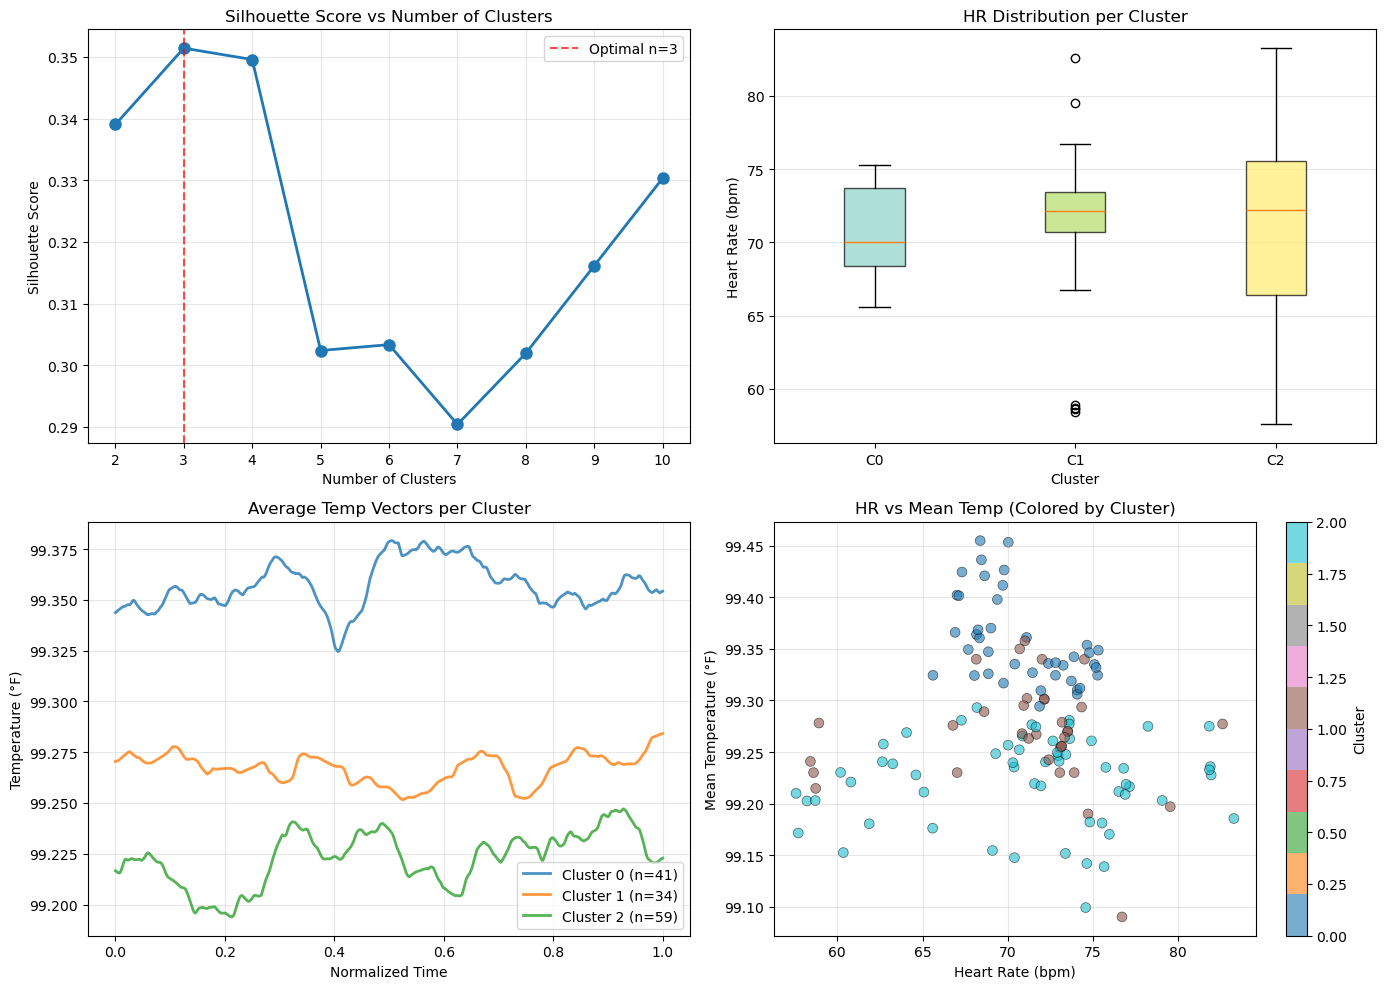


CLUSTER LABELS BY HEART RATE
Cluster 0 → Mean HR: 70.82 bpm
Cluster 1 → Mean HR: 70.99 bpm
Cluster 2 → Mean HR: 71.05 bpm

Clustering results stored in 'clustering_results' dictionary


In [11]:
# Visualization of clustering results

fig = plt.figure(figsize=(14, 10))

# 1. Silhouette scores
ax1 = plt.subplot(2, 2, 1)
ax1.plot(list(n_clusters_range), silhouette_scores, 'o-', linewidth=2, markersize=8)
ax1.axvline(x=optimal_n, color='r', linestyle='--', alpha=0.7, label=f'Optimal n={optimal_n}')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('Silhouette Score vs Number of Clusters')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. HR distribution per cluster
ax2 = plt.subplot(2, 2, 2)
cluster_hr_data = [np.array(block_hrs)[cluster_labels_features == i] for i in range(optimal_n)]
bp1 = ax2.boxplot(cluster_hr_data, tick_labels=[f'C{i}' for i in range(optimal_n)], patch_artist=True)
colors = plt.cm.Set3(np.linspace(0, 1, optimal_n))
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Heart Rate (bpm)')
ax2.set_title('HR Distribution per Cluster')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Average temperature vectors per cluster
ax3 = plt.subplot(2, 2, 3)
for cluster_id in range(optimal_n):
    cluster_mask = cluster_labels_features == cluster_id
    cluster_vectors = [block_vectors[i] for i in range(len(block_vectors)) if cluster_mask[i]]
    if len(cluster_vectors) > 0:
        # Interpolate to common length for visualization
        max_len = max(len(v) for v in cluster_vectors)
        interpolated = []
        for vec in cluster_vectors:
            if len(vec) < max_len:
                x_old = np.linspace(0, 1, len(vec))
                x_new = np.linspace(0, 1, max_len)
                vec_interp = np.interp(x_new, x_old, vec)
                interpolated.append(vec_interp)
            else:
                interpolated.append(vec[:max_len])
        avg_vec = np.mean(interpolated, axis=0)
        x_plot = np.linspace(0, 1, len(avg_vec))
        ax3.plot(x_plot, avg_vec, label=f'Cluster {cluster_id} (n={np.sum(cluster_mask)})', 
                linewidth=2, alpha=0.8)
ax3.set_xlabel('Normalized Time')
ax3.set_ylabel('Temperature (°F)')
ax3.set_title('Average Temp Vectors per Cluster')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Scatter: HR vs Mean Temp colored by cluster
ax4 = plt.subplot(2, 2, 4)
mean_temps = [np.mean(vec) for vec in block_vectors]
scatter = ax4.scatter(block_hrs, mean_temps, c=cluster_labels_features, 
                     cmap='tab10', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
ax4.set_xlabel('Heart Rate (bpm)')
ax4.set_ylabel('Mean Temperature (°F)')
ax4.set_title('HR vs Mean Temp (Colored by Cluster)')
ax4.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax4, label='Cluster')

plt.tight_layout()
plt.show()

# Create labeled cluster assignments
print("\n" + "=" * 60)
print("CLUSTER LABELS BY HEART RATE")
print("=" * 60)

# Clustering labels
cluster_hr_mapping = {}
for cluster_id in range(optimal_n):
    cluster_mask = cluster_labels_features == cluster_id
    cluster_hrs = np.array(block_hrs)[cluster_mask]
    mean_hr = np.mean(cluster_hrs)
    cluster_hr_mapping[cluster_id] = mean_hr
    print(f"Cluster {cluster_id} → Mean HR: {mean_hr:.2f} bpm")

# Store results for further analysis
clustering_results = {
    'kmeans': kmeans_features,
    'scaler': scaler,
    'cluster_labels': cluster_labels_features,
    'n_clusters': optimal_n,
    'hr_mapping': cluster_hr_mapping,
    'block_vectors': block_vectors,
    'block_hrs': block_hrs
}

print(f"\n{'='*60}")
print("Clustering results stored in 'clustering_results' dictionary")
print(f"{'='*60}")
